# Top 10 programming languages 2020 vs 2024

Curious about how programming languages have shifted over just a few years? 🤔 I downloaded data from Stack Overflow for 2020 and 2024 to explore how the most popular programming languages have changed, especially as I dive deeper into learning Python. 

Here are some key takeaways: 

🔹 Python is on the rise 📈, growing by over 5,000 users in just 4 years—no surprise, it's the go-to for AI, data science, and machine learning. 

🔹 TypeScript is booming 🌐, with a nearly 60% increase in popularity, overtaking older languages like PHP. 

🔹 PHP has seen a decline 📉, making room for JavaScript and Python in web development.

As we move into the future, I believe data-centric technologies like Python, SQL, and TypeScript will keep growing. With the rise of AI, automation, and cloud computing, the demand for versatile, scalable solutions will be higher than ever. 🌍💻

The tech landscape in 2024 is definitely looking data-driven, collaborative, and AI-powered.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the 2024 data
data_2024 = pd.read_csv('survey_results_public_2024.csv')

# Load the 2020 data
data_2020 = pd.read_csv('survey_results_public_2020.csv')


In [2]:
# Process 2024 languages
all_languages_2024 = data_2024['LanguageHaveWorkedWith'].dropna().str.cat(sep=';')
language_list_2024 = all_languages_2024.split(';')
language_df_2024 = pd.DataFrame(language_list_2024, columns=['Language'])
language_counts_2024 = language_df_2024['Language'].value_counts()

# Check if PHP is in the top 10; if not, explicitly add it
top_10_languages_2024 = language_counts_2024.head(10)
if 'PHP' not in top_10_languages_2024.index:
    top_10_languages_2024 = language_counts_2024.head(11)  # Include 11 to get PHP

# Process 2020 languages
all_languages_2020 = data_2020['LanguageWorkedWith'].dropna().str.cat(sep=';')
language_list_2020 = all_languages_2020.split(';')
language_df_2020 = pd.DataFrame(language_list_2020, columns=['Language'])
language_counts_2020 = language_df_2020['Language'].value_counts()
top_10_languages_2020 = language_counts_2020.head(10)

In [3]:
# Convert to DataFrame for merging
top_10_df_2024 = top_10_languages_2024.reset_index()
top_10_df_2024.columns = ['Language', 'Count_2024']

top_10_df_2020 = top_10_languages_2020.reset_index()
top_10_df_2020.columns = ['Language', 'Count_2020']

# Merge the dataframes on Language
comparison_df = pd.merge(top_10_df_2020, top_10_df_2024, on='Language', how='outer').fillna(0)

print(comparison_df)

                   Language  Count_2020  Count_2024
0   Bash/Shell (all shells)         0.0     20412.0
1     Bash/Shell/PowerShell     18980.0         0.0
2                         C         0.0     12184.0
3                        C#     18041.0     16318.0
4                       C++     13707.0     13827.0
5                  HTML/CSS     36181.0     31816.0
6                      Java     23074.0     18239.0
7                JavaScript     38822.0     37492.0
8                       PHP     15007.0     10951.0
9                    Python     25287.0     30719.0
10                      SQL     31413.0     30682.0
11               TypeScript     14578.0     23150.0


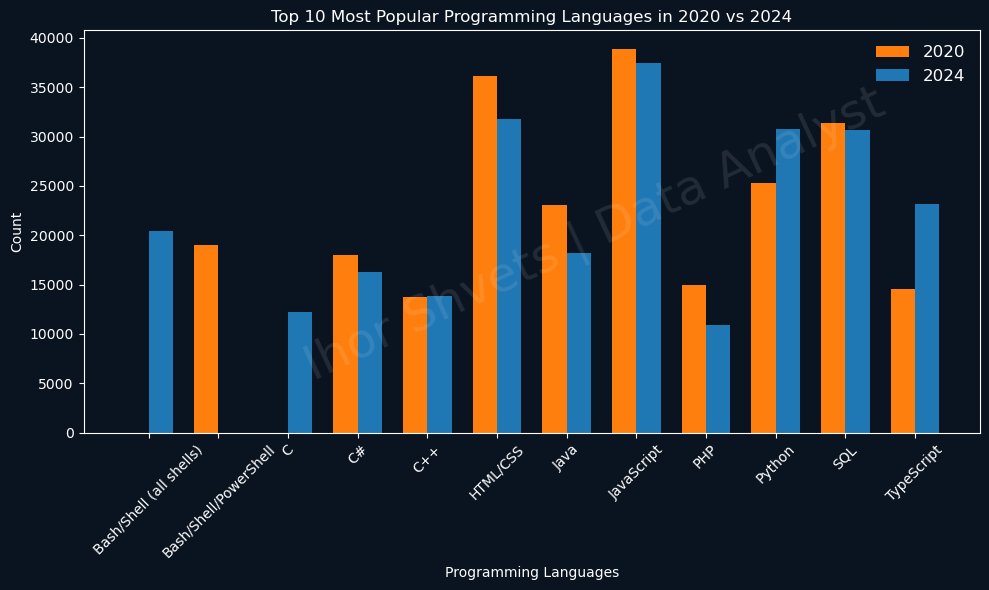

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Data
languages = comparison_df['Language']
counts_2020, counts_2024 = comparison_df['Count_2020'], comparison_df['Count_2024']
x = np.arange(len(languages))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a1320')  
ax.set_facecolor('#0a1320') 

# Bars
rects1 = ax.bar(x - 0.175, counts_2020, 0.35, label='2020', color='#ff7f0e')  # Orange
rects2 = ax.bar(x + 0.175, counts_2024, 0.35, label='2024', color='#1f77b4')  # Blue

# labels, title, and legend with white text
ax.set_xlabel('Programming Languages', color='white')
ax.set_ylabel('Count', color='white')
ax.set_title('Top 10 Most Popular Programming Languages in 2020 vs 2024', color='white')
ax.set_xticks(x)
ax.set_xticklabels(languages, rotation=45, color='white')
ax.tick_params(axis='y', labelcolor='white')
ax.legend(frameon=False, fontsize=12, labelcolor='white')

# Add watermark
# Add less visible watermark
fig.text(0.60, 0.60, 'Ihor Shvets | Data Analyst', 
         ha='center', va='center', 
         fontsize=35, color='white', 
         alpha=0.1, rotation=25, transform=fig.transFigure)

# Change axis and tick mark colors to white
plt.tight_layout()
for spine in ax.spines.values():
    spine.set_color('white')  # border color to white
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.show()  # Display the plot